# Comparison of deep learning models for arrhythmia detection

## Initialisation

In [2]:
# Imports
import os
import pandas as pd
import numpy as np
import torch
import wfdb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# Folder with data in CSV format
csv_folder = "./csv_output"

# Initialize empty lists to store the ECG and annotations
ecg_signals = []
annotations = []

# Loop through each CSV file in the folder
for file in os.listdir(csv_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_folder, file)
        
        # Load the CSV into a DataFrame
        df = pd.read_csv(file_path)
        
        # Ensure the CSV has at least 4 columns
        if len(df.columns) >= 4:
            # Extract the 1st column (ECG Signal) and 4th column (Annotation)
            # Convert the ECG signal column to a NumPy array and append to ecg_signals
            ecg_signals.append(np.array(df.iloc[:, 0].values))  # First column (ECG Signal)
            
            # Extract the annotations and append to annotations (make sure the length matches)
            annotations.append(df.iloc[:, 3].values)  # Fourth column (Annotation)
        else:
            print(f"Warning: File {file} does not have at least 4 columns")
            

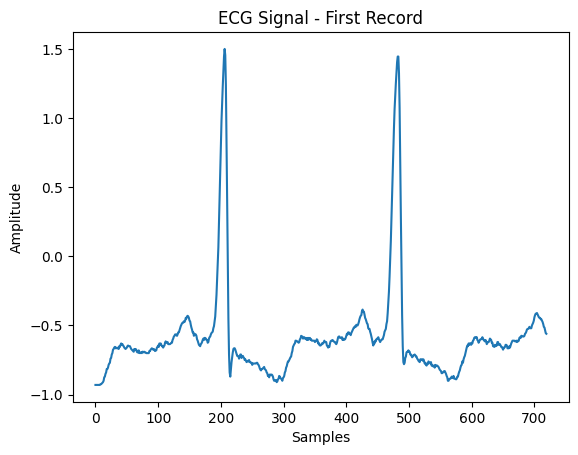

In [3]:
# Plot the first record
plt.plot(ecg_signals[0][:720])  # Plot the first beat.

# Adding title and labels
plt.title("ECG Signal - First Record")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

# Display the plot
plt.show()

## Data Preprocessing

### Filtering 

### Segmentation

### Normalisation

## Models

### MLP with feature extract layer

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        
        # Feature extraction layer
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### Standard CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNN, self).__init__()
        
        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### LSTM

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.dropout(x)
        x = self.fc(x)
        return x

### Hybrid

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(CNN_LSTM, self).__init__()
        
        # Feature extraction layers (CNN)
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # LSTM for sequence modeling
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.permute(0, 2, 1)  # Reshape for LSTM (batch, seq_len, features)
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.classifier(x)
        return x


### Transformer

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, num_classes, num_heads=4, num_layers=2, dim_feedforward=128):
        super(TransformerModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=num_heads, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv1(x)
        x = x.permute(2, 0, 1)  # Reshape for Transformer (seq_len, batch, features)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)  # Global Average Pooling
        x = self.dropout(x)
        x = self.fc(x)
        return x

## Training

## Testing

## Evaluation